# Odgen Material Model

The Ogden material model is approximated using an invariant-based formulation and compared with the experimental results reported in [1].

## Reference

[1] Oliver A. Shergold, *The uniaxial stress versus strain response of pig skin
and silicone rubber at low and high strain rates*, 2004

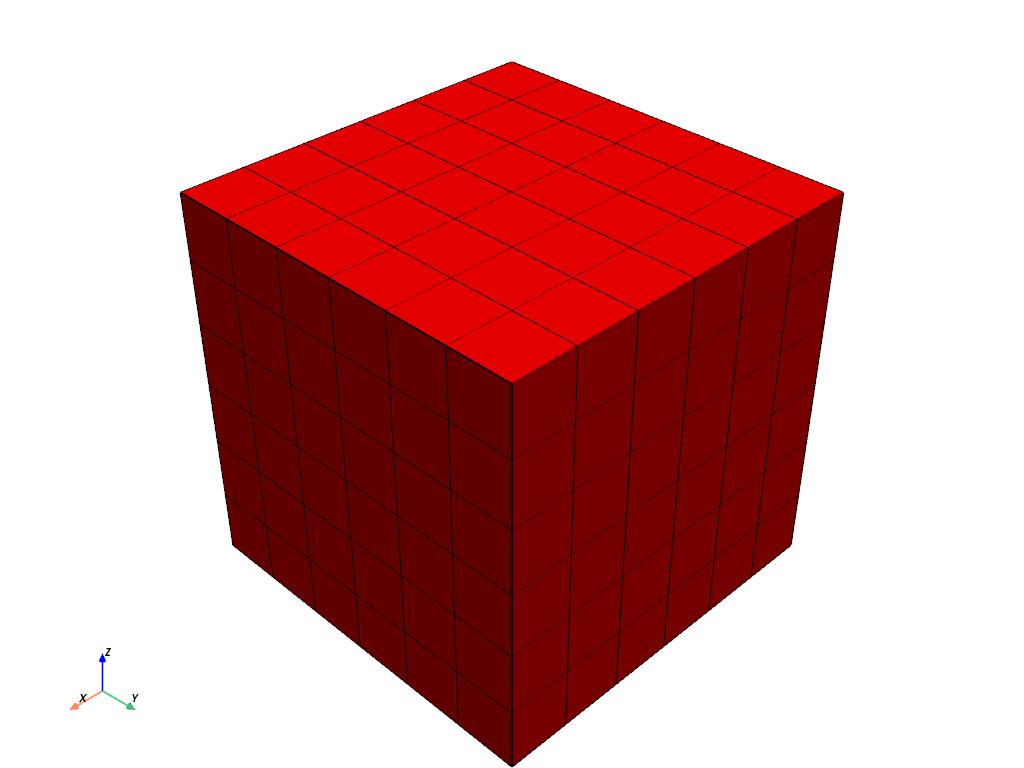

In [7]:
import dolfinx.fem.petsc
from mpi4py import MPI
import viskex
import pyvista
import numpy as np
import ufl
from matplotlib import pyplot as plt

pyvista.set_jupyter_backend("static")

L       = 10
A0      = L * L
n_el    = 6
element = ("Lagrange", 2, (3,))

lower_point = [0, 0, 0]
upper_point = [L, L, L]

domain = dolfinx.mesh.create_box(MPI.COMM_WORLD, [lower_point, upper_point], [n_el, n_el, n_el], dolfinx.mesh.CellType.hexahedron)

viskex.dolfinx.plot_mesh(domain)

In [8]:
V = dolfinx.fem.functionspace(domain, element)

def top(x):
    return np.isclose(x[2], L)

def bottom(x):
    return np.isclose(x[2], 0)

def xz_plane(x):
    return np.isclose(x[1], 0)

def yz_plane(x):
    return np.isclose(x[0], 0)

fdim = domain.topology.dim - 1
top_facets      = dolfinx.mesh.locate_entities_boundary(domain, fdim, top)
bottom_facets   = dolfinx.mesh.locate_entities_boundary(domain, fdim, bottom)
xz_facets       = dolfinx.mesh.locate_entities_boundary(domain, fdim, xz_plane)
yz_facets       = dolfinx.mesh.locate_entities_boundary(domain, fdim, yz_plane)

upper_dofs = dolfinx.fem.locate_dofs_topological(V.sub(2), fdim, top_facets)
lower_dofs = dolfinx.fem.locate_dofs_topological(V.sub(2), fdim, bottom_facets)
xz_dofs    = dolfinx.fem.locate_dofs_topological(V.sub(1), fdim, xz_facets)
yz_dofs    = dolfinx.fem.locate_dofs_topological(V.sub(0), fdim, yz_facets)

u_upper  = dolfinx.fem.Constant(domain, 0.0)
u_zero   = dolfinx.default_scalar_type(0.0)

lower_bc    = dolfinx.fem.dirichletbc(u_zero, lower_dofs, V.sub(2))
upper_bc    = dolfinx.fem.dirichletbc(u_upper, upper_dofs, V.sub(2))
xz_bc       = dolfinx.fem.dirichletbc(u_zero, xz_dofs, V.sub(1))
yz_bc       = dolfinx.fem.dirichletbc(u_zero, yz_dofs, V.sub(0))
bcs         = [lower_bc, upper_bc, xz_bc, yz_bc]

uh = dolfinx.fem.Function(V)
du = ufl.TrialFunction(V)
v  = ufl.TestFunction(V)

def odgen_fit(alpha, mu, lam_max):

    beta    = alpha / 2
    nu      = 0.495
    kappa   = 2 * mu * (1 + nu) / 3 / (1 - 2 * nu)
    u_max   = L * (lam_max - 1)
    steps   = 20
    
    I = ufl.Identity(3)
    F = ufl.variable(I + ufl.grad(uh))
    C = F.T * F
    J = ufl.det(F)

    quadrature_metadata = {"quadrature_degree": 4}

    I1_bar  = J**(-2.0/3.0) * ufl.tr(C)
    psi_iso = mu / (2.0 * beta * 3.0 ** (beta - 1.0)) * (I1_bar**beta - 3.0**beta)
    psi_vol = 0.5 * kappa * (J - 1.0)**2
    psi     = psi_iso + psi_vol

    dx  = ufl.Measure("dx", domain=domain, metadata=quadrature_metadata)
    Pi  = psi * dx
    R   = ufl.derivative(Pi, uh, v)
    Jac = ufl.derivative(R, uh, du)

    facet_tags = dolfinx.mesh.meshtags(
        domain, fdim, top_facets,
        np.full(len(top_facets), 1, dtype=np.int32),
    )
    ds = ufl.Measure(
        "ds", domain=domain, subdomain_data=facet_tags, metadata=quadrature_metadata
    )

    N   = ufl.FacetNormal(domain)
    ez  = ufl.as_vector([0.0, 0.0, 1.0])
    P   = ufl.diff(psi, F)
    reaction_form = dolfinx.fem.form(ufl.dot(P * N, ez) * ds(1))

    problem = dolfinx.fem.petsc.NonlinearProblem(R, uh,
                                                J=Jac, bcs=bcs,
                                                petsc_options_prefix="odgen_",
                                                petsc_options={"ksp_type":"preonly", "pc_type":"lu"})

    lam     = np.zeros(steps)
    sigma   = np.zeros(steps)
    for i in range(steps):
        u_upper.value = u_max * (i + 1) / steps
        u = problem.solve()

        Rz      = dolfinx.fem.assemble_scalar(reaction_form)
        stress  = Rz / A0
        strain  = u_upper.value / L
        stretch = strain + 1.0

        lam[i]      = stretch
        sigma[i]    = stress

        print(f"{i+1:03d}, {stretch: .6f}, {stress: .6f}")

    return u, lam, sigma


EPS_DOT = 0.4/s, COMPRESSION
001,  0.972500, -0.033845
002,  0.945000, -0.069803
003,  0.917500, -0.108219
004,  0.890000, -0.149498
005,  0.862500, -0.194115
006,  0.835000, -0.242632
007,  0.807500, -0.295719
008,  0.780000, -0.354179
009,  0.752500, -0.418976
010,  0.725000, -0.491281
011,  0.697500, -0.572521
012,  0.670000, -0.664454
013,  0.642500, -0.769262
014,  0.615000, -0.889674
015,  0.587500, -1.029142
016,  0.560000, -1.192076
017,  0.532500, -1.384181
018,  0.505000, -1.612925
019,  0.477500, -1.888228
020,  0.450000, -2.223475
EPS_DOT = 4000/s, COMPRESSION
001,  0.972500, -0.236875
002,  0.945000, -0.488621
003,  0.917500, -0.757536
004,  0.890000, -1.046487
005,  0.862500, -1.358802
006,  0.835000, -1.698422
007,  0.807500, -2.070036
008,  0.780000, -2.479254
009,  0.752500, -2.932834
010,  0.725000, -3.438964
011,  0.697500, -4.007646
012,  0.670000, -4.651181
013,  0.642500, -5.384834
014,  0.615000, -6.227717
015,  0.587500, -7.203991
016,  0.560000, -8.344534
017, 

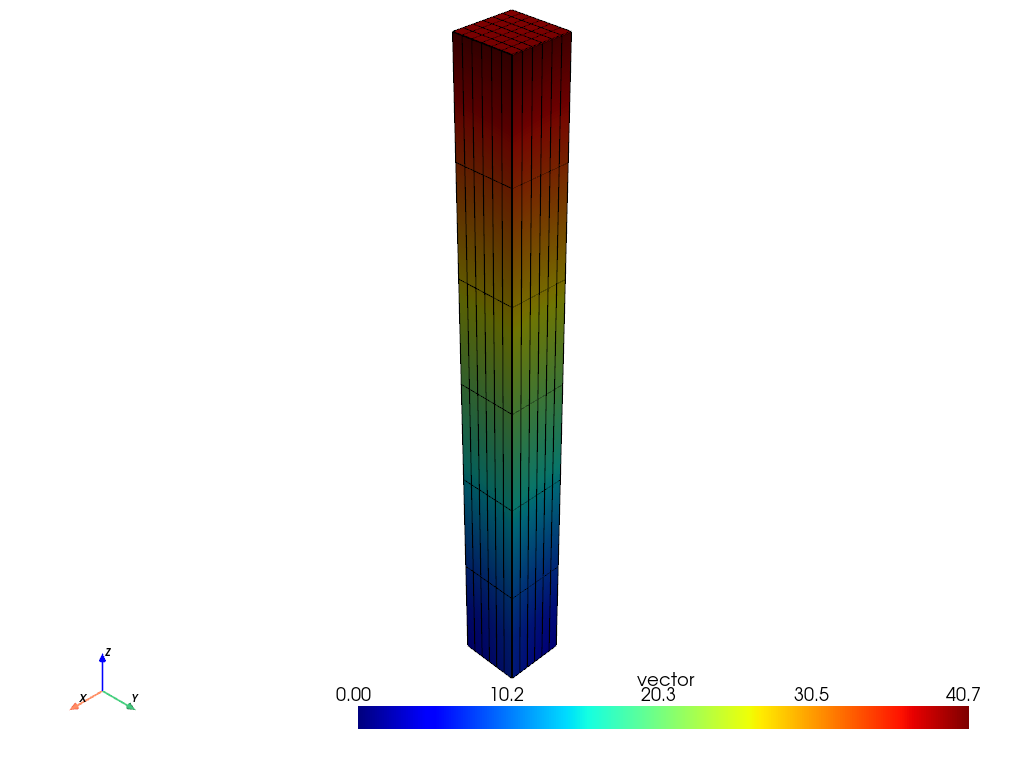

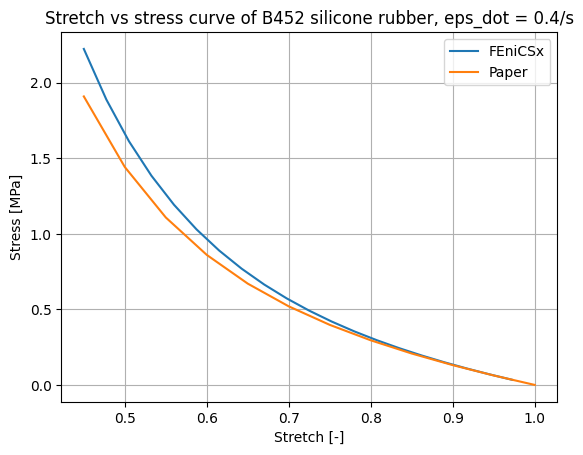

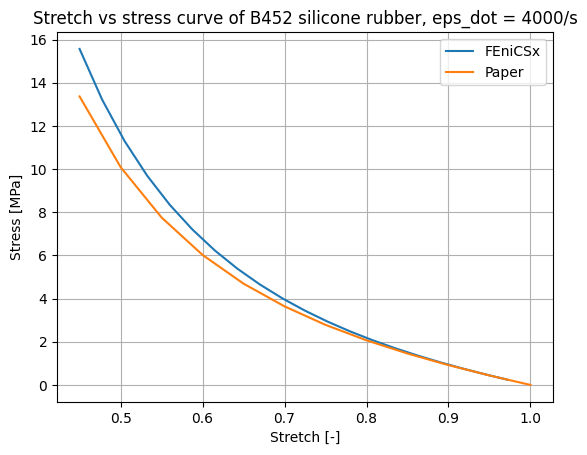

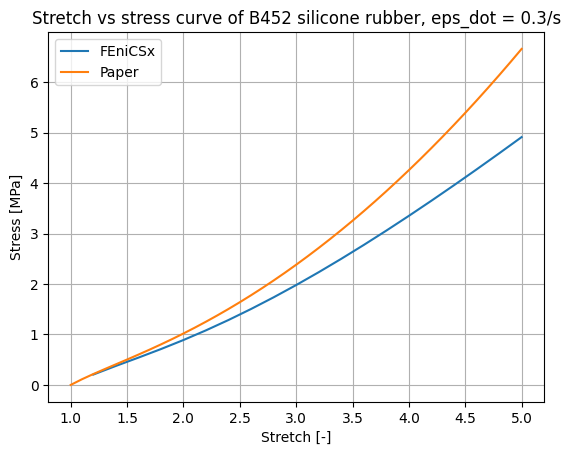

In [9]:
compression = np.array([
# lambda    0.004/s   4000/s
 [1.00,     0.0000,   0.0000],
 [0.95,     0.0625,   0.4374],
 [0.90,     0.1310,   0.9172],
 [0.85,     0.2077,   1.4537],
 [0.80,     0.2952,   2.0663],
 [0.75,     0.3974,   2.7819],
 [0.70,     0.5198,   3.6386],
 [0.65,     0.6702,   4.6914],
 [0.60,     0.8603,   6.0220],
 [0.55,     1.1080,   7.7560],
 [0.50,     1.4418,   10.0928],
 [0.45,     1.9091,   13.3635],
])

tension = np.array([
    # lambda, 0.3/s
    [1.0, 0.0000],
    [1.1, 0.1125],
    [1.2, 0.2149],
    [1.3, 0.3123],
    [1.4, 0.4077],
    [1.5, 0.5032],
    [1.6, 0.6003],
    [1.7, 0.6999],
    [1.8, 0.8027],
    [1.9, 0.9091],
    [2.0, 1.0195],
    [2.1, 1.1343],
    [2.2, 1.2535],
    [2.3, 1.3774],
    [2.4, 1.5061],
    [2.5, 1.6397],
    [2.6, 1.7782],
    [2.7, 1.9217],
    [2.8, 2.0703],
    [2.9, 2.2240],
    [3.0, 2.3829],
    [3.1, 2.5469],
    [3.2, 2.7161],
    [3.3, 2.8905],
    [3.4, 3.0702],
    [3.5, 3.2550],
    [3.6, 3.4452],
    [3.7, 3.6405],
    [3.8, 3.8412],
    [3.9, 4.0471],
    [4.0, 4.2583],
    [4.1, 4.4748],
    [4.2, 4.6966],
    [4.3, 4.9237],
    [4.4, 5.1561],
    [4.5, 5.3938],
    [4.6, 5.6368],
    [4.7, 5.8851],
    [4.8, 6.1387],
    [4.9, 6.3976],
    [5.0, 6.6619],
])

# EPS_DOT = 0.4/s, COMPRESSION
alpha   = 3.0
mu      = 0.4
lam_max = 0.45
print("EPS_DOT = 0.4/s, COMPRESSION")
u, lam, sigma = odgen_fit(alpha, mu, lam_max)

plt.figure(1)
plt.plot(lam, abs(sigma))
plt.plot(compression[:, 0], compression[:, 1])
plt.legend(["FEniCSx", "Paper"])
plt.grid(True)
plt.xlabel("Stretch [-]")
plt.ylabel("Stress [MPa]")
plt.title("Stretch vs stress curve of B452 silicone rubber, eps_dot = 0.4/s")

# EPS_DOT = 4000/s, COMPRESSION
alpha   = 3.0
mu      = 2.8
lam_max = 0.45
print("EPS_DOT = 4000/s, COMPRESSION")
u, lam, sigma = odgen_fit(alpha, mu, lam_max)

plt.figure(2)
plt.plot(lam, abs(sigma))
plt.plot(compression[:, 0], compression[:, 2])
plt.legend(["FEniCSx", "Paper"])
plt.grid(True)
plt.xlabel("Stretch [-]")
plt.ylabel("Stress [MPa]")
plt.title("Stretch vs stress curve of B452 silicone rubber, eps_dot = 4000/s")

# EPS_DOT = 0.3/s, TENSION
# 0.4/s values are used since 0.3/s isn't given
alpha   = 3.0
mu      = 0.4
lam_max = 5.0
print("EPS_DOT = 0.3/s, TENSION")
u, lam, sigma = odgen_fit(alpha, mu, lam_max)

plt.figure(3)
plt.plot(lam, abs(sigma))
plt.plot(tension[:, 0], tension[:, 1])
plt.legend(["FEniCSx", "Paper"])
plt.grid(True)
plt.xlabel("Stretch [-]")
plt.ylabel("Stress [MPa]")
plt.title("Stretch vs stress curve of B452 silicone rubber, eps_dot = 0.3/s")

viskex.dolfinx.plot_vector_field(u, warp_factor=1.0)